<a href="https://colab.research.google.com/github/Bkishorek/Healthcare-Data-Analytics-Portfolio/blob/main/Life_Expectancy_ML_Project%20/Life_Expectancy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cleaned data from MS excel is imported to colab for futher analysis and Model Formulation.


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Life_Expectancy_data_cleaned dataset.csv", encoding="latin1")
df.head()
df.shape

(2938, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2938 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [5]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,69.224847,164.796460,30.303948,4.602672,738.251295,80.932845,2419.592240,38.321001,42.035739,82.549864,5.935252,82.323928,1.742103,7483.149553,1.275338e+07,4.839244,4.870660,0.625985,11.993193
std,4.613841,9.507640,124.080302,117.926501,3.916288,1987.914858,22.586860,11467.272489,19.927677,160.445548,23.352143,2.400295,23.640073,5.077785,13136.800417,5.381546e+07,4.394537,4.482709,0.204919,3.264382
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.200000,74.000000,0.000000,1.092500,4.685343,80.900000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,580.486996,4.189172e+05,1.600000,1.600000,0.504250,10.300000
50%,2008.000000,72.000000,144.000000,3.000000,4.160000,64.912906,87.000000,17.000000,43.000000,4.000000,93.000000,5.900000,93.000000,0.100000,3116.561755,3.675929e+06,3.400000,3.400000,0.662000,12.100000
75%,2012.000000,75.600000,227.000000,22.000000,7.390000,441.534144,96.000000,360.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,7483.100000,1.275338e+07,7.100000,7.200000,0.772000,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [6]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

Data intepretation

suggests there is significant variations in  in life expectancy  among countries.this tells us disparities in healthcare systems and socia-economic xonditions worldwide.



In [7]:
#Correlational analysis
correlation_matrix = df.corr(numeric_only=True)

life_corr = correlation_matrix['Life expectancy '].sort_values(ascending = False)

print(life_corr)

Life expectancy                    1.000000
Schooling                          0.715044
Income composition of resources    0.693807
 BMI                               0.559258
Diphtheria                         0.475425
Polio                              0.461587
GDP                                0.430495
Alcohol                            0.391602
percentage expenditure             0.381794
Total expenditure                  0.207971
Hepatitis B                        0.203883
Year                               0.169612
Population                        -0.019637
Measles                           -0.157572
infant deaths                     -0.196533
under-five deaths                 -0.222501
 thinness 5-9 years               -0.466709
 thinness  1-19 years             -0.472037
 HIV/AIDS                         -0.556454
Adult Mortality                   -0.696359
Name: Life expectancy , dtype: float64


In [8]:
#STATISTICAL MODELLING AND HYPOTHESIS TESTING

import statsmodels.api as sm
x = df[['Schooling','GDP', 'infant deaths',' thinness  1-19 years' ]]
y = df['Life expectancy ']

x= sm.add_constant(x)
model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Life expectancy    R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     916.0
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:54:18   Log-Likelihood:                -9594.2
No. Observations:                2938   AIC:                         1.920e+04
Df Residuals:                    2933   BIC:                         1.923e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    50.23

In [9]:
#Model formulation
#Impoorting required libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [10]:
# selecting important predictors (avioid highly correlated duplicates)
x = df[['Adult Mortality', ' HIV/AIDS', ' BMI ', 'Income composition of resources',  'Schooling']]
y = df['Life expectancy ']

In [11]:
#train- test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
# Model Training
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [13]:
#Coefficients

coefficients = pd.DataFrame({
        "Feature" : x.columns,
        "Coefficient" : model.coef_
        })
print(coefficients)

                           Feature  Coefficient
0                  Adult Mortality    -0.023000
1                         HIV/AIDS    -0.463968
2                             BMI      0.062281
3  Income composition of resources     9.436600
4                        Schooling     0.871458


In [14]:
#MODEL EVALUATION
 # Model Accuracy(R2 score)

r2 = model.score(x_test, y_test)
print("R-squared:", r2)

R-squared: 0.7734123058107043


In [15]:
#Model evaluation(MEAN ABSOLUTE ERROR, ROOT MEAN SQUARED ERROR)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
np.sqrt(mean_squared_error(y_test,y_pred))
print("MAE", mae)
print("RMSE:", rmse)


MAE 3.2097776051048648
RMSE: 4.430629764886448


In [16]:
#testing model with values
new_data = np.array([[271,0.1,18.6,0.476,10]])
prediction = model.predict(new_data)

print("Predicted Life Expectancy:",
      prediction[0])

Predicted Life Expectancy: 63.1845482017914


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


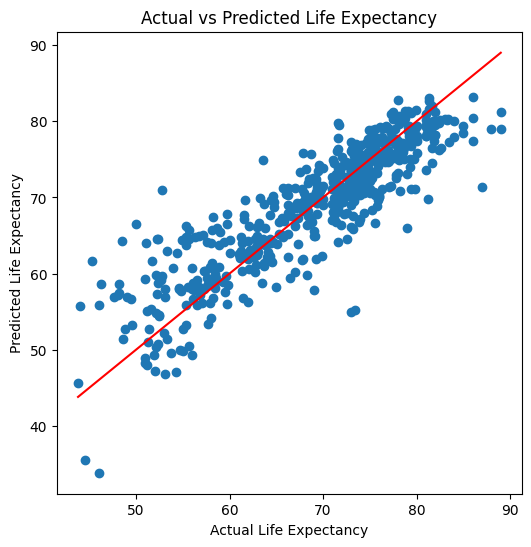

In [17]:
#Visuals explaining models
###1. ACTUAL LIFE EXPECTANCY VS PREDICTED LIFE EXPECTANCY PLOT ######

import matplotlib.pyplot as plt

#prediction using test data (important)
y_pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")

#Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],color = 'red')

plt.show()


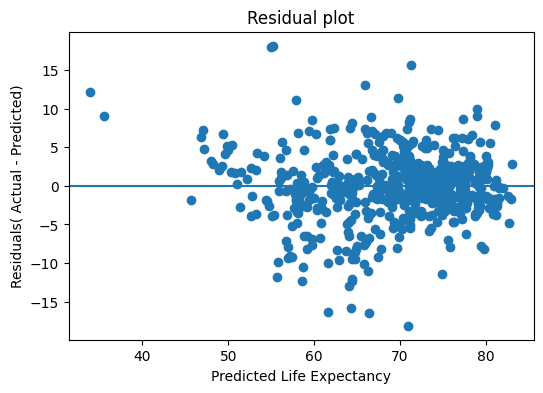

In [18]:
## RESIDUAL PLOT

y_pred = model.predict(x_test)
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred , residuals)
plt.axhline(0)
plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residuals( Actual - Predicted)")
plt.title("Residual plot")
plt.show()

INSIGHTS FROM ANALYSIS


The regression model demonstrates strong predictive performance with an R² value of 0.77, explaining 77% of the variation in life expectancy. The average prediction error is approximately 3.2 years (MAE), with an RMSE of 4.43 years, indicating moderate but stable prediction accuracy. Visual analysis through the Actual vs Predicted plot confirms strong alignment between observed and estimated values. The residual distribution suggests that linear regression assumptions are reasonably satisfied. Feature analysis highlights that mortality-related and socioeconomic factors significantly influence life expectancy outcomes.